In [9]:
#import pandas, pickle, seaborn, and matplotlib

import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [10]:
#create CovidTravelDF using US covid and travel data csv

CovidTravelDF = pd.read_csv("US_Covid_and_Travel_Data.csv")

#display first few lines of CovidTravelDF to check that everything is being read properly
CovidTravelDF.head()

,Year,Month_number,Month,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths,Foreign_originating,Foreign_returning,US_citizen_originating,US_citizen_returning,Timestamp
0,2020,1,January,8,8,0,0,5274405,5520357,4073096,5218812,2020-01
1,2020,2,February,61,69,1,1,4470729,4448720,3902937,4155775,2020-02
2,2020,3,March,173074,173143,3326,3327,1960896,2946059,1844726,3053096,2020-03
3,2020,4,April,857163,1030306,57134,60461,54031,176627,32144,110285,2020-04
4,2020,5,May,755116,1785422,44864,105325,78337,192614,54368,107630,2020-05


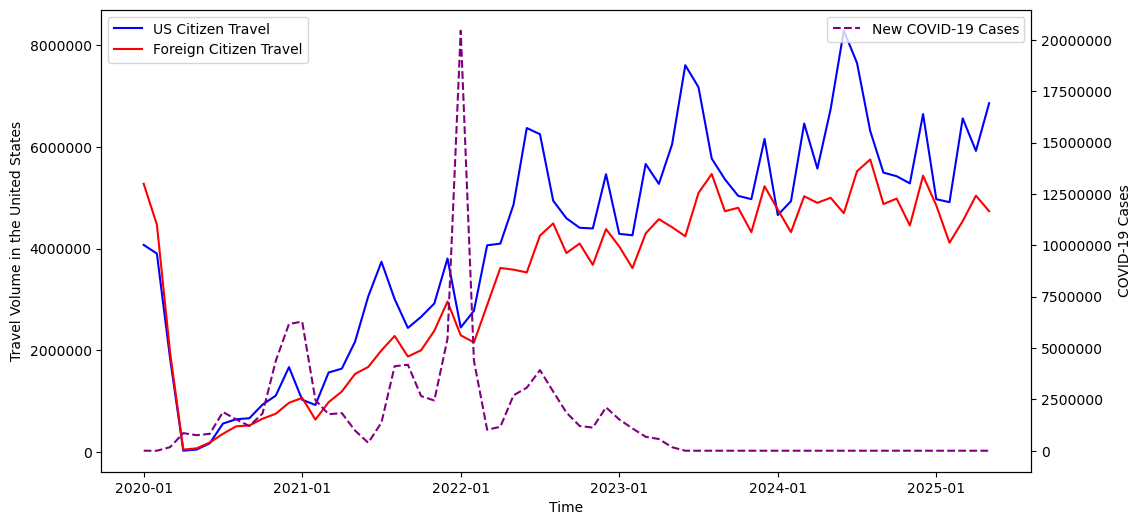

In [16]:
#creates a figure (f) and a main axis (ax1) and sets the figure size to 12 x 6
f, ax1 = plt.subplots(figsize = (12,6))

#plots a blue line on the main Y axis (ax1) showing US citizen travel over time
sns.lineplot(data=CovidTravelDF, x="Timestamp", y="US_citizen_originating", ax=ax1, color="blue", label="US Citizen Travel", errorbar=None)
#plots a red line on the main Y axis (ax1) showing Foreign citizen travel over time
sns.lineplot(data=CovidTravelDF, x="Timestamp", y="Foreign_originating", ax=ax1, color="red", label="Foreign Citizen Travel", errorbar=None)

#labels the main Y axis as "Travel Volume in the United States"
ax1.set_ylabel("Travel Volume in the United States")
#labels the x axis as "Time"
ax1.set_xlabel("Time")

#creates a secondary Y axis (ax2)
ax2 = ax1.twinx()
#plots a purple dashed line on the secondary Y axis (ax2) showing New COVID Cases over time
sns.lineplot(data=CovidTravelDF, x="Timestamp", y="New_cases", ax=ax2, color="purple", linestyle = "--", label="New COVID-19 Cases", errorbar=None)

#labels the secondary Y axis as COVID Cases
ax2.set_ylabel("COVID-19 Cases")

#changes the ticks on the x axis so that only every 12th one shows (making it show one per year)
ax1.set_xticks(ax1.get_xticks()[::12])

#formats both Y axes to show the plain number, rather than scientific notation
ax1.ticklabel_format(style='plain', axis='y')
ax2.ticklabel_format(style='plain', axis='y')



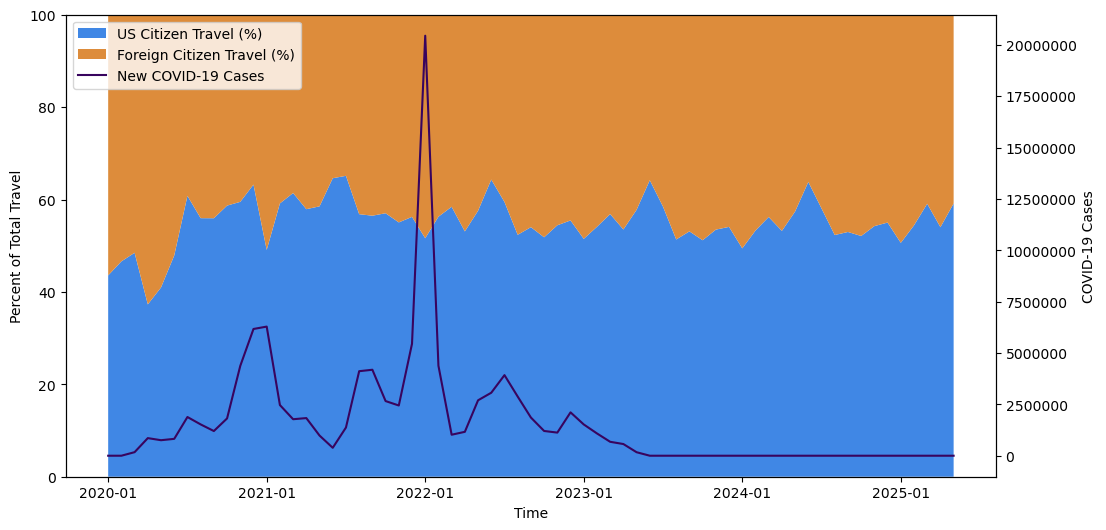

In [15]:
#creates a column that finds the sum of US citizen and Foreign citizen travel
CovidTravelDF["Total_travel"] = CovidTravelDF["US_citizen_originating"] + CovidTravelDF["Foreign_originating"]
#creates a column that finds the percent of total travel that US citizens made up
CovidTravelDF["US_percent"] = (CovidTravelDF["US_citizen_originating"]/CovidTravelDF["Total_travel"]) * 100
#creates a column that finds the percent of total travel that Foreign citizens made up
CovidTravelDF["Foreign_percent"] = (CovidTravelDF["Foreign_originating"]/CovidTravelDF["Total_travel"]) * 100

#creates a figure (f) and a main Y axis (ax1) and sets the figure size to 12x6
fig, ax1 = plt.subplots(figsize = (12,6))

#plots a stacked area chart on ax1 which shows the percent contribution of both US and foreign citizens to overall travel
ax1.stackplot(CovidTravelDF["Timestamp"],
              CovidTravelDF["US_percent"],
              CovidTravelDF["Foreign_percent"],
              labels = ["US Citizen Travel (%)", "Foreign Citizen Travel (%)"],
              colors = ["#4087e5", "#dd8c3b"])

#labels the main Y axis as "Percent of Total Travel"
ax1.set_ylabel("Percent of Total Travel")
#labels the X axis as Time
ax1.set_xlabel("Time")
#sets limits on the main Y axis so that it will only ever show 0-100 (which is the most that it should show since we are looking at percent)
ax1.set_ylim(0,100)

#creates a secondary Y axis (ax2)
ax2 = ax1.twinx()
#plots a line on the secondary Y axis tracking the number of new covid cases over time
ax2.plot(CovidTravelDF["Timestamp"], 
         CovidTravelDF["New_cases"],
         color = "#38045e",
         label = "New COVID-19 Cases")
#labels the secondary Y axis as COVID Cases
ax2.set_ylabel("COVID-19 Cases")

#changes the ticks on the x axis so that only every 12th one shows (making it show one per year)
ax1.set_xticks(ax1.get_xticks()[::12])
#formats both Y axes to show the plain number, rather than scientific notation
ax1.ticklabel_format(style='plain', axis='y')
ax2.ticklabel_format(style='plain', axis='y')

#gets the handles and labels for the legend items on ax1 and ax2
travel_handles, travel_labels = ax1.get_legend_handles_labels()
covid_handles, covid_labels = ax2.get_legend_handles_labels()

#combines both lengends that are shown above and places them in the upper left hand corner of the visualization
ax1.legend(travel_handles + covid_handles,
           travel_labels + covid_labels,
           loc = "upper left")

In [ ]:
#load the COVID-19 daily data from a csv file into a table named CovidGlobalDF
CovidGlobalDF = pd.read_csv("WHO-COVID-19-global-daily-data.csv")

#Display the first few rows of CovidGlobalDF to check the structure of the data
CovidGlobalDF.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-04,VC,Saint Vincent and the Grenadines,AMR,NaN,0,NaN,0
1,2020-01-04,SN,Senegal,AFR,NaN,0,NaN,0
2,2020-01-04,SB,Solomon Islands,WPR,0.0,0,0.0,0
3,2020-01-04,LK,Sri Lanka,SEAR,0.0,0,0.0,0
4,2020-01-04,SY,Syrian Arab Republic,EMR,NaN,0,NaN,0


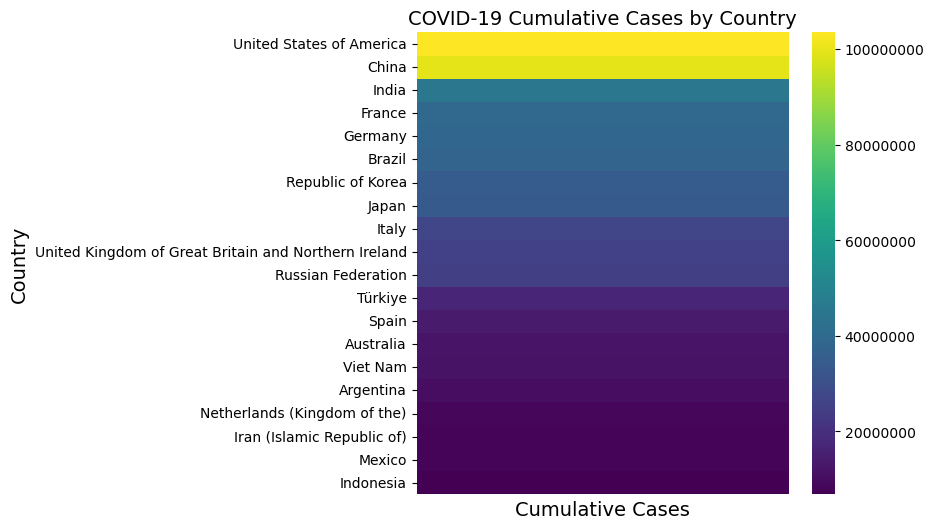

In [17]:
#Group the data by country
# For each country, find the highest number of cumulative COVID-19 cases
# Store this in a new table called
latestCases = CovidGlobalDF.groupby("Country")["Cumulative_cases"].max().reset_index()

# From the latestCases table, select the top 20 countries with the highest number of cumulative cases
# Save this subset as top20
top20 = latestCases.nlargest(20, "Cumulative_cases")

#preparing the data for the heatmap
#set "Country" as the index (row labels)
#get the values of "cumulative_cases" and reshape them into a column vector
#save this as top20_data
top20_data = top20.set_index("Country")["Cumulative_cases"].values.reshape(-1,1)

# Created a square figure to hold the heatmap (6x6 inches in size)
plt.figure(figsize=(6,6))

# Sort the top 20 countries again in descending order based on their case counts.
# Save this as sorted_df
sorted_df = top20.sort_values(by='Cumulative_cases', ascending=False)

# Created a heatmap
# Used the sorted data to show only the cumulative case counts
ax = sns.heatmap(sorted_df[['Cumulative_cases']],
                 yticklabels=sorted_df['Country'],
                 xticklabels=False,
                 cmap='viridis',
                 cbar_kws={"format": ScalarFormatter()})

# Added a color bar for reference and format its labels to show full numbers
colorbar = ax.collections[0].colorbar
colorbar.formatter.set_scientific(False)
colorbar.formatter.set_useOffset(False)
colorbar.update_ticks()

# Customized the plot
# Labeled the x-axis as "Cumulative Cases"
ax.set_xlabel("Cumulative Cases", fontsize=14)
# Label the y-axis as "Country"
ax.set_ylabel("Country", fontsize=14)

# Set a title for the plot: "COVID-19 Cumulative Cases by Country"
plt.title('COVID-19 Cumulative Cases by Country', fontsize=14)
# Display the heatmap
plt.show()